In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('cs-training.csv', index_col=0)

print("📊 DATASET OVERVIEW")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean()*100:.1f}%")
df.head()

Saving cs-training.csv to cs-training.csv
📊 DATASET OVERVIEW
Rows: 150,000
Columns: 11

Column names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Default rate: 6.7%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
print("🔍 MISSING VALUES ANALYSIS")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

missing = pd.DataFrame({
    'Missing Values': nulos,
    'Percentage (%)': nulos_pct
}).query('`Missing Values` > 0')

print(missing)

df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)
print("\n✅ Missing values handled")

🔍 MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

✅ Missing values handled


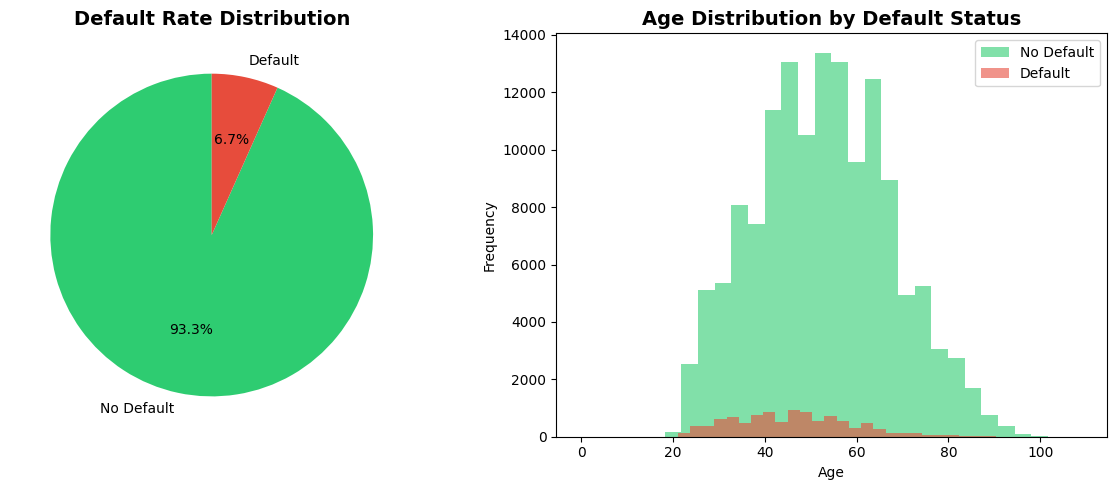

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['No Default', 'Default']
sizes = df['SeriousDlqin2yrs'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Default Rate Distribution', fontsize=14, fontweight='bold')

# Age distribution by default
df[df['SeriousDlqin2yrs']==0]['age'].plot(kind='hist', ax=axes[1],
    alpha=0.6, color='#2ecc71', label='No Default', bins=30)
df[df['SeriousDlqin2yrs']==1]['age'].plot(kind='hist', ax=axes[1],
    alpha=0.6, color='#e74c3c', label='Default', bins=30)
axes[1].set_title('Age Distribution by Default Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('default_distribution.png', dpi=150)
plt.show()

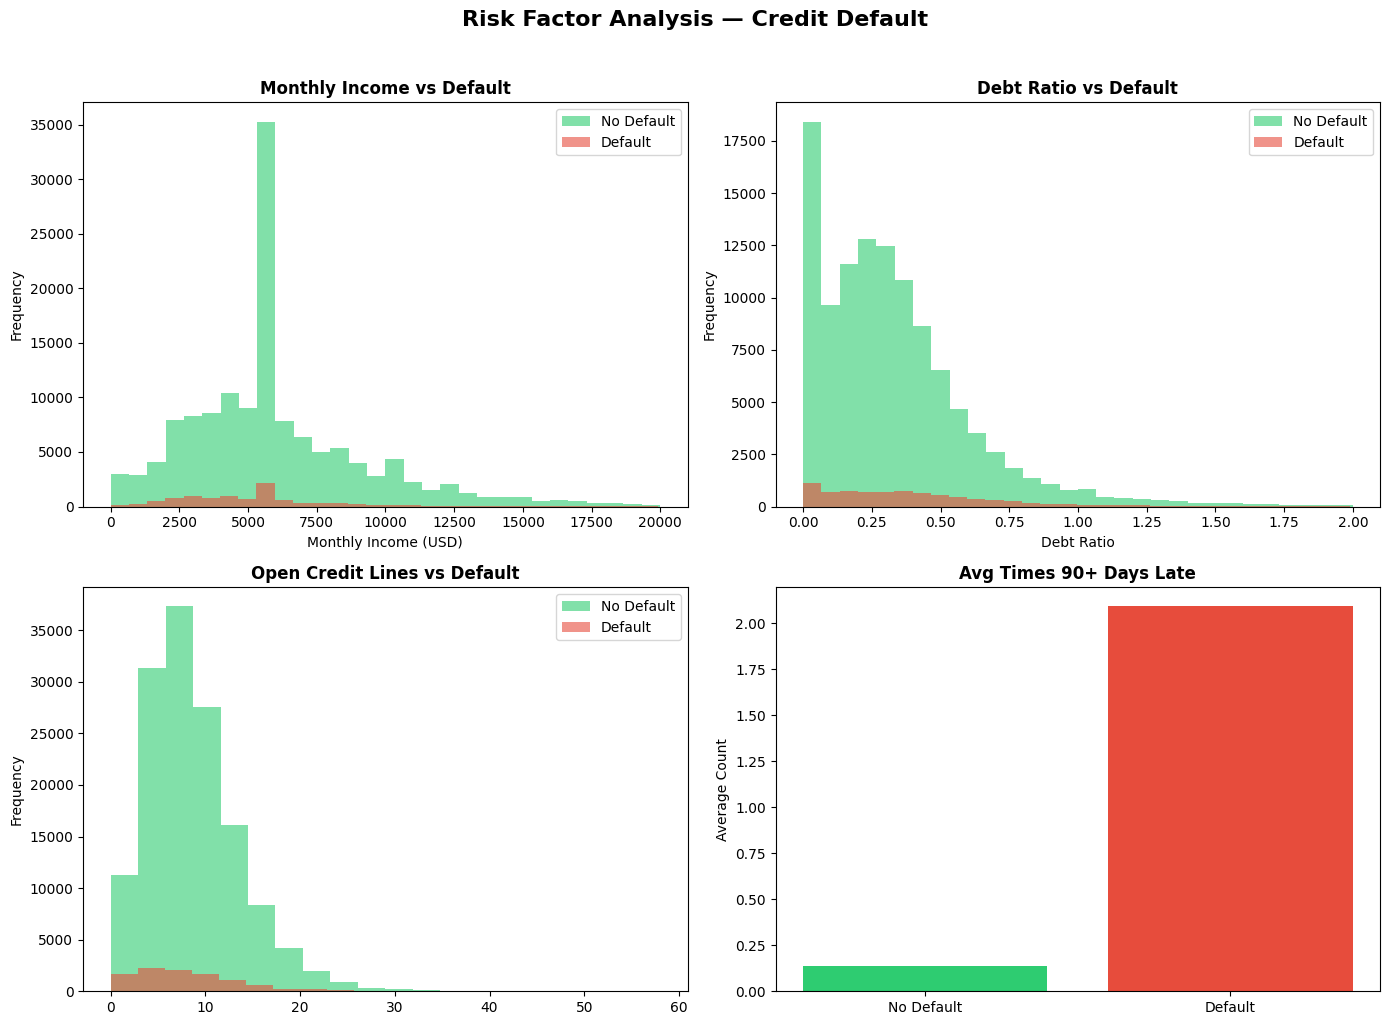

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Ingreso mensual vs default
df_clean = df[df['MonthlyIncome'] < 20000]
df_clean[df_clean['SeriousDlqin2yrs']==0]['MonthlyIncome'].plot(
    kind='hist', ax=axes[0,0], alpha=0.6, color='#2ecc71', label='No Default', bins=30)
df_clean[df_clean['SeriousDlqin2yrs']==1]['MonthlyIncome'].plot(
    kind='hist', ax=axes[0,0], alpha=0.6, color='#e74c3c', label='Default', bins=30)
axes[0,0].set_title('Monthly Income vs Default', fontweight='bold')
axes[0,0].set_xlabel('Monthly Income (USD)')
axes[0,0].legend()

# 2. Deuda vs ingreso
df_clean2 = df[df['DebtRatio'] < 2]
df_clean2[df_clean2['SeriousDlqin2yrs']==0]['DebtRatio'].plot(
    kind='hist', ax=axes[0,1], alpha=0.6, color='#2ecc71', label='No Default', bins=30)
df_clean2[df_clean2['SeriousDlqin2yrs']==1]['DebtRatio'].plot(
    kind='hist', ax=axes[0,1], alpha=0.6, color='#e74c3c', label='Default', bins=30)
axes[0,1].set_title('Debt Ratio vs Default', fontweight='bold')
axes[0,1].set_xlabel('Debt Ratio')
axes[0,1].legend()

# 3. Líneas de crédito abiertas
df[df['SeriousDlqin2yrs']==0]['NumberOfOpenCreditLinesAndLoans'].plot(
    kind='hist', ax=axes[1,0], alpha=0.6, color='#2ecc71', label='No Default', bins=20)
df[df['SeriousDlqin2yrs']==1]['NumberOfOpenCreditLinesAndLoans'].plot(
    kind='hist', ax=axes[1,0], alpha=0.6, color='#e74c3c', label='Default', bins=20)
axes[1,0].set_title('Open Credit Lines vs Default', fontweight='bold')
axes[1,0].legend()

# 4. Veces con 90+ días de retraso
retraso = df.groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].mean()
axes[1,1].bar(['No Default', 'Default'], retraso.values, color=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Avg Times 90+ Days Late', fontweight='bold')
axes[1,1].set_ylabel('Average Count')

plt.suptitle('Risk Factor Analysis — Credit Default', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('risk_factors.png', dpi=150)
plt.show()

In [7]:
features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
            'NumberOfDependents']

X = df[features]
y = df['SeriousDlqin2yrs']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("🤖 MODEL PERFORMANCE")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

🤖 MODEL PERFORMANCE
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     28044
     Default       0.51      0.16      0.24      1956

    accuracy                           0.94     30000
   macro avg       0.73      0.57      0.60     30000
weighted avg       0.92      0.94      0.92     30000



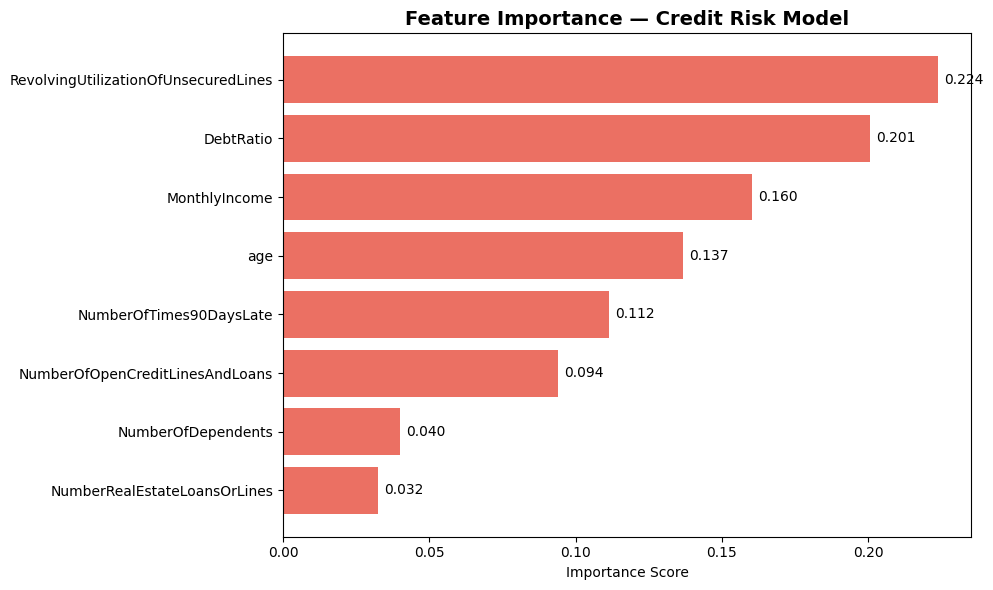


✅ Most important factor: RevolvingUtilizationOfUnsecuredLines


In [8]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances['Feature'], importances['Importance'], color='#e74c3c', alpha=0.8)
ax.set_title('Feature Importance — Credit Risk Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, importances['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("\n✅ Most important factor:", importances.iloc[-1]['Feature'])